In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
from torch_geometric.nn.conv import GATConv, GCNConv, SplineConv
from torch_geometric.nn.norm import GraphNorm
from torch_geometric.nn import Sequential
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import torch.utils.data as torchdata
import tqdm
from math import floor
import gc
import matplotlib.pyplot as plt
from Model.MENDR.MENDR import MENDR_model
from Model.MENDR.MENDREncoder import MENDRPatchEncoder
from Model.MENDR.mAtt.optimizer import MixOptimizer
import random
import os
import math
from Datasets.datasetTUAB import WaveletTUABDataset
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, precision_recall_curve, auc
from torchjd import mtl_backward
from torchjd.aggregation import UPGrad

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
print("*" * 50)
finetune_train_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/train")
print("Dataset Loaded. Length of Train Dataset: ", len(finetune_train_dataset))
finetune_eval_dataset = WaveletTUABDataset(root="/home/hice1/mchen439/scratch/downstreamTaskData/eval")
print("Dataset Loaded. Length of Validation Dataset: ", len(finetune_eval_dataset))

**************************************************
Loading 2130 folders


100%|██████████| 2130/2130 [01:46<00:00, 19.97it/s]


Dataset Loaded. Length of Train Dataset:  44854
Loading 253 folders


100%|██████████| 253/253 [00:10<00:00, 23.98it/s]

Dataset Loaded. Length of Validation Dataset:  5101


In [6]:
print(finetune_eval_dataset[0]['graph'].x.shape)
print(finetune_eval_dataset[0]['delta'].shape)
print(finetune_eval_dataset[0]['theta'].shape)
print(finetune_eval_dataset[0]['alpha'].shape)
print(finetune_eval_dataset[0]['beta'].shape)
print(finetune_eval_dataset[0]['gamma'].shape)

(19, 7680)
torch.Size([19, 246])
torch.Size([19, 246])
torch.Size([19, 486])
torch.Size([19, 966])
torch.Size([19, 1925])


In [7]:
finetune_train_loader = DataLoader(finetune_train_dataset, batch_size=256, num_workers=8, shuffle=True, persistent_workers=True)
finetune_eval_loader = DataLoader(finetune_eval_dataset, batch_size=256, num_workers=8, shuffle=True, persistent_workers=True)
print(len(finetune_train_loader), len(finetune_eval_loader))
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']

176 20


In [8]:
class FinetuneDecoder(nn.Module):
    def __init__(self, device):
        super(FinetuneDecoder, self).__init__()

        #self.max_pool = nn.AvgPool1d(6, stride=3) 
        L_out = 18 + 2 * (0) - 1 * (6 - 1) - 1
        L_out = floor((L_out / 3) + 1)

        self.band_decoders = nn.ParameterDict({
            'delta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'theta': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'alpha': nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'beta':  nn.Sequential(nn.GELU(), nn.Linear(38 * 18, 19)),
            'gamma': nn.Sequential(nn.GELU(), nn.Linear(76 * 18, 19)),
        })

        self.band_decoders_out = nn.Sequential(nn.LayerNorm(95), nn.GELU(), nn.Linear(95, 95))
        self.final_decoder = nn.Linear(95, 1)

    def forward(self, x):
        band_decodings = []
        for band, encodings in x.items():
            #encodings = self.max_pool(encodings) 
            encodings = encodings.view(encodings.shape[0], encodings.shape[1]*encodings.shape[2])
            band_decoding = self.band_decoders[band](encodings)
            band_decodings.append(band_decoding)
        band_decodings = torch.cat(band_decodings, dim=1)
        band_decodings = self.band_decoders_out(band_decodings)
        return self.final_decoder(band_decodings)



In [9]:
model = MENDR_model(device=device).to(device)
model_decoder = FinetuneDecoder(device).to(device)
optim_params = []
optim_params += list(model.parameters())
optim_params += list(model_decoder.parameters())
optimizer = MixOptimizer(torch.optim.AdamW(optim_params, lr=1e-3))
optimizer.set_scheduler_t0(len(finetune_train_loader))
aggregator = UPGrad(pref_vector=torch.tensor([1e3, 0.01, 0.1, 1, 10, 100]).to(device))
print("Total parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Total parameters:", sum(p.numel() for p in model_decoder.parameters() if p.requires_grad))
total_encoder_params = 0
total_decoder_params = 0
for band in BANDS:
    print(f'{band} Encoder Params: {model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()}')
    print(f'{band} Decoder Params: {model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()}')
    total_encoder_params += model.mendr_encoder.encoder_decoders[band].getEncoderParamCount()
    total_decoder_params += model.mendr_encoder.encoder_decoders[band].getDecoderParamCount()
print("Total Encoder Params: ", total_encoder_params)
print("Total Decoder Params: ", total_decoder_params)

Set Cosine Annealing with Warm Restarts optimizer T_0 to: 176
Total parameters: 213279
Total parameters: 87477
delta Encoder Params: 1881
delta Decoder Params: 7539
theta Encoder Params: 1881
theta Decoder Params: 7539
alpha Encoder Params: 3325
alpha Decoder Params: 11699
beta Encoder Params: 6213
beta Decoder Params: 28179
gamma Encoder Params: 11989
gamma Decoder Params: 111411
Total Encoder Params:  25289
Total Decoder Params:  166367


In [10]:
def calculate_band_loss(inputs, outputs, band_model, loss_fn):
    outputs_reshaped = outputs.reshape(inputs.shape[0], inputs.shape[1], inputs.shape[2], inputs.shape[3])
    loss = loss_fn(inputs, outputs_reshaped)
    return loss

In [11]:
def train_one_epoch(model, epoch, decoder, optimizer, task_loss_fn, recon_loss_fn, train_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.train()
	decoder.train()

	pbar = tqdm.trange(len(train_loader), desc="Training")
	data_iterator = iter(train_loader)
	balanced_accuracies = []

	for iteration in pbar:
		data = next(data_iterator)
		relevant_bands = [data['delta'].float().to(device),
							data['theta'].float().to(device),
							data['alpha'].float().to(device),
							data['beta'].float().to(device),
							data['gamma'].float().to(device)]
		inputs = dict(zip(BANDS, relevant_bands))
		patchified_inputs, encodings, decodings = model(data['graph'], inputs)
		prediction = decoder(encodings).float()
		ground_truth = data['graph'].y.to(device).float()
		ground_truth = torch.repeat_interleave(ground_truth, patchified_inputs['delta'].shape[1]) 

		task_loss = task_loss_fn(prediction, ground_truth[:, None])

		delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], model.mendr_encoder.encoder_decoders['delta'], recon_loss_fn)
		theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], model.mendr_encoder.encoder_decoders['theta'], recon_loss_fn)
		alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], model.mendr_encoder.encoder_decoders['alpha'], recon_loss_fn)
		beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], model.mendr_encoder.encoder_decoders['beta'], recon_loss_fn)
		gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], model.mendr_encoder.encoder_decoders['gamma'], recon_loss_fn)

		with torch.no_grad():
			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
			precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
			pr_auc = auc(recall, precision)

		shared_features = [encoding for band, encoding in encodings.items()]
		balanced_accuracies.append(balanced_accuracy)
		optimizer.zero_grad()
		mtl_backward(losses=[task_loss, delta_loss, theta_loss, alpha_loss, beta_loss, gamma_loss], features=shared_features, aggregator=aggregator)
		optimizer.step()
		optimizer.scheduler_step(epoch * len(train_loader) + iteration)
		task_loss_sum += task_loss.item()
		recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
		recon_loss_sum += recon_loss
		pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
	balanced_accuracies = np.array(balanced_accuracies)	
	print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return task_loss_sum, recon_loss_sum

In [14]:
def validate_one_epoch(model, decoder, task_loss_fn, recon_loss_fn, val_loader):
	task_loss_sum = 0
	recon_loss_sum = 0
	model.eval()
	decoder.eval()

	pbar = tqdm.trange(len(val_loader), desc="Validating")
	data_iterator = iter(val_loader)
	balanced_accuracies = []

	with torch.no_grad():
		for iteration in pbar:
			data = next(data_iterator)
			relevant_bands = [data['delta'].float().to(device),
								data['theta'].float().to(device),
								data['alpha'].float().to(device),
								data['beta'].float().to(device),
								data['gamma'].float().to(device)]
			inputs = dict(zip(BANDS, relevant_bands))
			encoder_outputs = model(data['graph'], inputs)
			patchified_inputs, encodings, decodings = model(data['graph'], inputs)
			prediction = decoder(encodings).float()
			ground_truth = data['graph'].y.to(device).float()
			ground_truth = torch.repeat_interleave(ground_truth, patchified_inputs['delta'].shape[1]) 

			task_loss = task_loss_fn(prediction, ground_truth[:, None])

			delta_loss = calculate_band_loss(patchified_inputs['delta'], decodings['delta'], model.mendr_encoder.encoder_decoders['delta'], recon_loss_fn)
			theta_loss = calculate_band_loss(patchified_inputs['theta'], decodings['theta'], model.mendr_encoder.encoder_decoders['theta'], recon_loss_fn)
			alpha_loss = calculate_band_loss(patchified_inputs['alpha'], decodings['alpha'], model.mendr_encoder.encoder_decoders['alpha'], recon_loss_fn)
			beta_loss = calculate_band_loss(patchified_inputs['beta'],   decodings['beta'], model.mendr_encoder.encoder_decoders['beta'], recon_loss_fn)
			gamma_loss = calculate_band_loss(patchified_inputs['gamma'], decodings['gamma'], model.mendr_encoder.encoder_decoders['gamma'], recon_loss_fn)

			score_y = torch.sigmoid(prediction)
			pred_y = torch.gt(score_y, 0.5).long().cpu().numpy()
			score_y = score_y.cpu().numpy()

			balanced_accuracy = balanced_accuracy_score(ground_truth.cpu().numpy(), pred_y)
			accuracy = accuracy_score(ground_truth.cpu().numpy(), pred_y)
			try:
				roc_auc = roc_auc_score(ground_truth.cpu().numpy(), score_y)
				precision, recall, thresholds = precision_recall_curve(ground_truth.cpu().numpy(), score_y, pos_label=1)
				pr_auc = auc(recall, precision)
			except:
				roc_auc = 0
				pr_auc = 0

			balanced_accuracies.append(balanced_accuracy)

			task_loss_sum += task_loss.item()
			recon_loss = delta_loss.item() + theta_loss.item() + alpha_loss.item() + beta_loss.item() + gamma_loss.item()
			recon_loss_sum += recon_loss

			pbar.set_postfix(task_loss=task_loss.item(), recon_loss=recon_loss, accuracy=f'{accuracy*100:.3f}', balanced_accuracy=f'{balanced_accuracy*100:.3f}', AUROC=f'{roc_auc*100:.3f}', AUCPR=f'{pr_auc*100:.3f}', lr=optimizer.scheduler.get_last_lr()[0])
		balanced_accuracies = np.array(balanced_accuracies)
		balanced_accuracies.mean(), balanced_accuracies.std()
		#print(f'Mean Acc: {balanced_accuracies.mean()} Acc Std: {balanced_accuracies.std()}')
	return task_loss_sum, recon_loss_sum, balanced_accuracies.mean(), balanced_accuracies.std()

In [15]:
BANDS = ['delta', 'theta', 'alpha', 'beta', 'gamma']
for epoch_idx in range(2):
    training_task_loss, training_recon_loss = train_one_epoch(model, epoch_idx, model_decoder, optimizer, nn.BCEWithLogitsLoss(), nn.L1Loss(), finetune_train_loader)
    eval_task_loss, eval_recon_loss, eval_acc, eval_std = validate_one_epoch(model, model_decoder, nn.BCEWithLogitsLoss(), nn.L1Loss(), finetune_eval_loader)
    print("*" * 50)
    print(f"Epoch: {epoch_idx}")
    print("Epoch: ", epoch_idx, "Total Training Task Loss: ", training_task_loss, "Total Training Recon Loss:", training_recon_loss, "Total Validation Task Loss: ", eval_task_loss, "Total Validation Recon Loss:", eval_recon_loss)
    print("Epoch: ", epoch_idx, "Eval Acc", eval_acc, "Eval Std", eval_std)

Training: 100%|██████████| 176/176 [01:55<00:00,  1.52it/s, AUCPR=81.312, AUROC=87.380, accuracy=80.303, balanced_accuracy=78.409, lr=1.8e-7, recon_loss=10.1, task_loss=0.449]  


Mean Acc: 0.7752259249451412 Acc Std: 0.023089235930093314


Validating: 100%|██████████| 20/20 [00:10<00:00,  1.86it/s, AUCPR=88.753, AUROC=89.558, accuracy=81.933, balanced_accuracy=80.198, lr=1.8e-7, recon_loss=11.2, task_loss=0.402]


**************************************************
Epoch: 0
Epoch:  0 Total Training Task Loss:  82.43143883347511 Total Training Recon Loss: 2258.0550687611103 Total Validation Task Loss:  8.686479449272156 Total Validation Recon Loss: 206.98858150839806
Epoch:  0 Eval Acc 0.7801707167327347 Eval Std 0.013953645676097979


Training: 100%|██████████| 176/176 [01:48<00:00,  1.62it/s, AUCPR=81.167, AUROC=81.253, accuracy=75.926, balanced_accuracy=74.544, lr=0.000505, recon_loss=11.4, task_loss=0.507]


Mean Acc: 0.7869180636349223 Acc Std: 0.021880375675134362


Validating: 100%|██████████| 20/20 [00:07<00:00,  2.53it/s, AUCPR=87.091, AUROC=89.276, accuracy=81.320, balanced_accuracy=79.087, lr=0.000505, recon_loss=8.98, task_loss=0.4]  

**************************************************
Epoch: 1
Epoch:  1 Total Training Task Loss:  79.45583871006966 Total Training Recon Loss: 2205.780316889286 Total Validation Task Loss:  8.298687219619751 Total Validation Recon Loss: 198.34991657733917
Epoch:  1 Eval Acc 0.7945961712775531 Eval Std 0.020900869822361473


In [20]:
pbar = tqdm.trange(len(finetune_eval_loader), desc="Validating")
data_iterator = iter(finetune_eval_loader)

model.eval()
model_decoder.eval()

encoding_outputs = dict()
decoding_outputs = dict()
combined_outputs = []
output_labels = []
predictions = []

for iteration in pbar:
    data = next(data_iterator)
    
    relevant_bands = [data['delta'].float().to(device),
                        data['theta'].float().to(device),
                        data['alpha'].float().to(device),
                        data['beta'].float().to(device),
                        data['gamma'].float().to(device)]

    inputs = dict(zip(BANDS, relevant_bands))

    with torch.no_grad():
        patchified_inputs, encodings, decodings = model(data['graph'], inputs)
        output_labels.append(torch.repeat_interleave(data['graph'].y, patchified_inputs['delta'].shape[1]))

        band_decodings = []
        for band, encoding in encodings.items():
            if band not in encoding_outputs:
                encoding_outputs[band] = []

            encoding_outputs[band].append(encoding)
            encoding = encoding.view(encoding.shape[0], -1)
            band_decoding = model_decoder.band_decoders[band](encoding)
            band_decodings.append(band_decoding)
        for band, decoding in decodings.items():
            if band not in decoding_outputs:
                decoding_outputs[band] = []
            decoding_outputs[band].append(decodings)

        combined_decoding = torch.cat(band_decodings, dim=1)

        combined_decoding = model_decoder.band_decoders_out(combined_decoding)
        prediction = model_decoder.final_decoder(combined_decoding)
        combined_outputs.append(combined_decoding)

        predictions.append(prediction)

combined_outputs = torch.cat(combined_outputs, dim=0)


Validating: 100%|██████████| 20/20 [00:07<00:00,  2.61it/s]


In [21]:
print(combined_outputs.shape)

torch.Size([56111, 95])


In [22]:
predictions = torch.cat(predictions, dim=0)
print(predictions.shape)

torch.Size([56111, 1])


In [23]:
encoding_output_eval_all = dict()
for band, encodings in encoding_outputs.items():
    encoding_output_eval_all[band] = torch.cat(encodings, dim=0).cpu().numpy()
    print(band, encoding_output_eval_all[band].shape)

combined_output_eval_all = combined_outputs.cpu().numpy()
output_labels_eval_all = torch.cat(output_labels, dim=0).cpu().numpy()
predictions = predictions.cpu().numpy()

delta (56111, 38, 18)
theta (56111, 38, 18)
alpha (56111, 38, 18)
beta (56111, 38, 18)
gamma (56111, 76, 18)


In [24]:
import umap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.decomposition import PCA
reducer2 = umap.UMAP(n_components=2)

/usr/local/pace-apps/manual/packages/anaconda3/2023.03/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/6 [00:00<?, ?it/s]

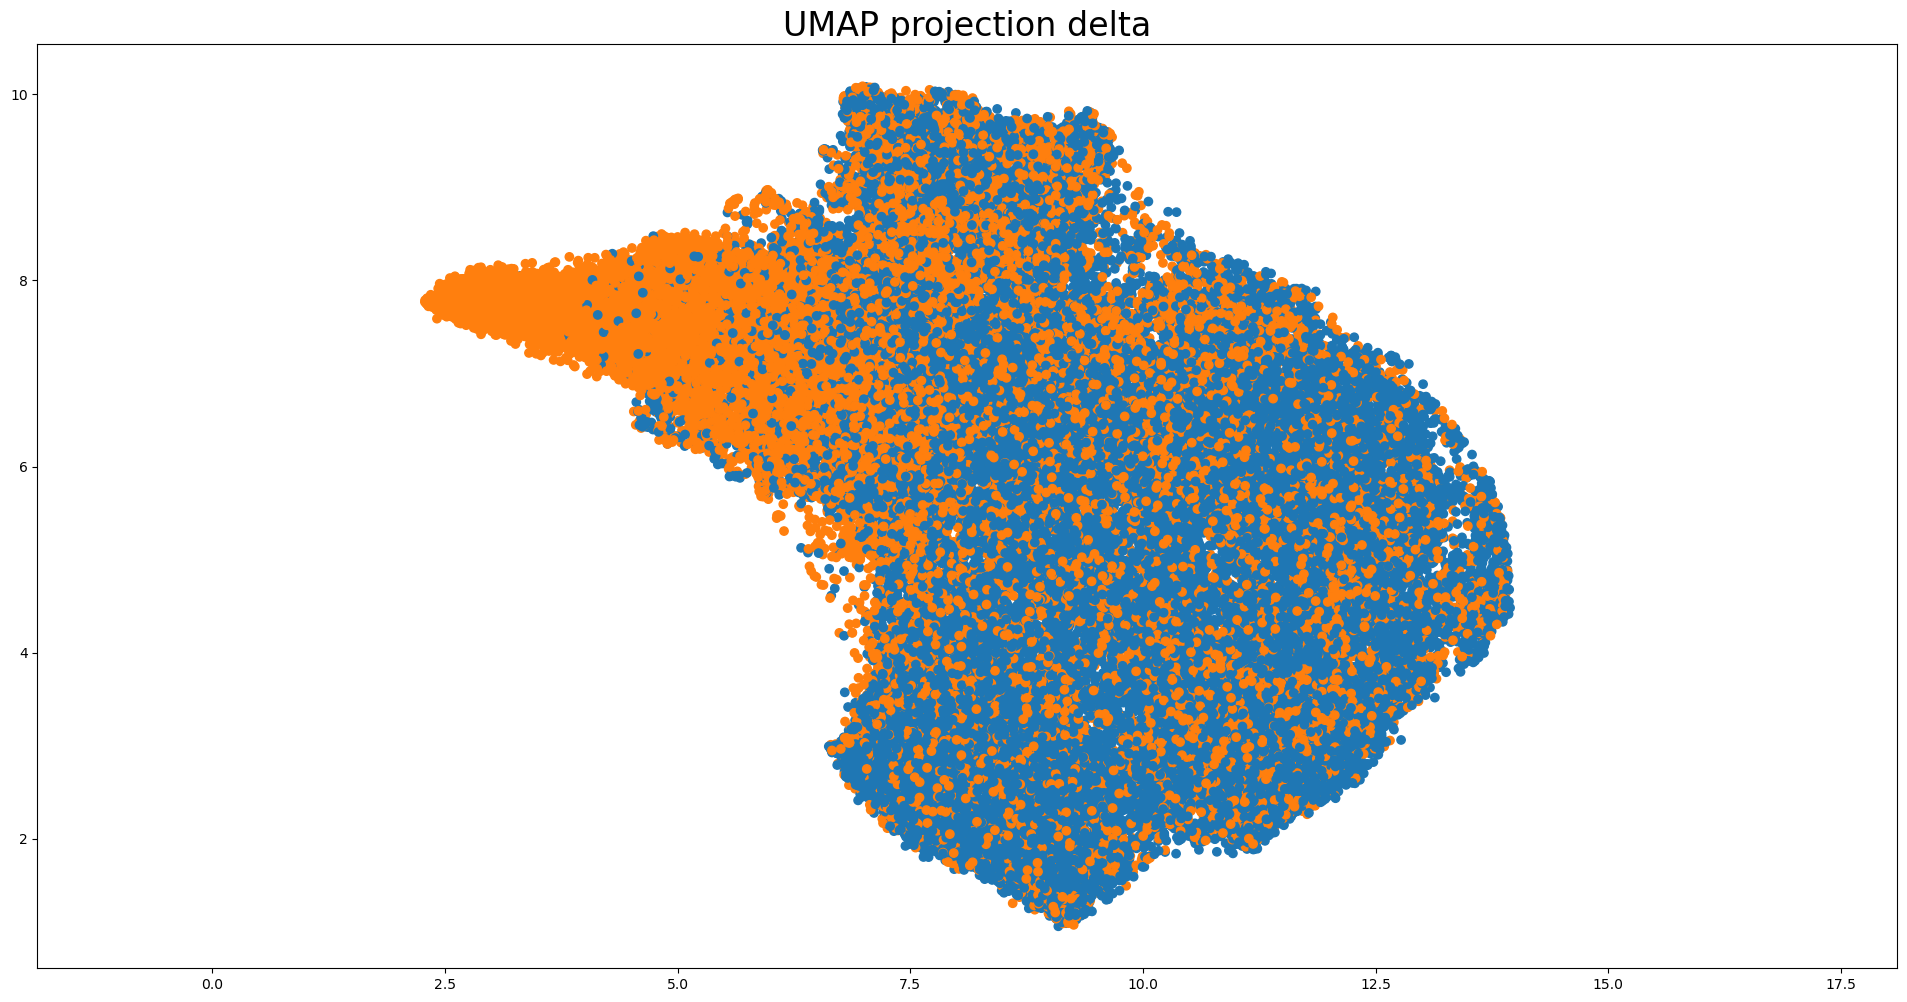

 17%|█▋        | 1/6 [00:26<02:12, 26.46s/it]

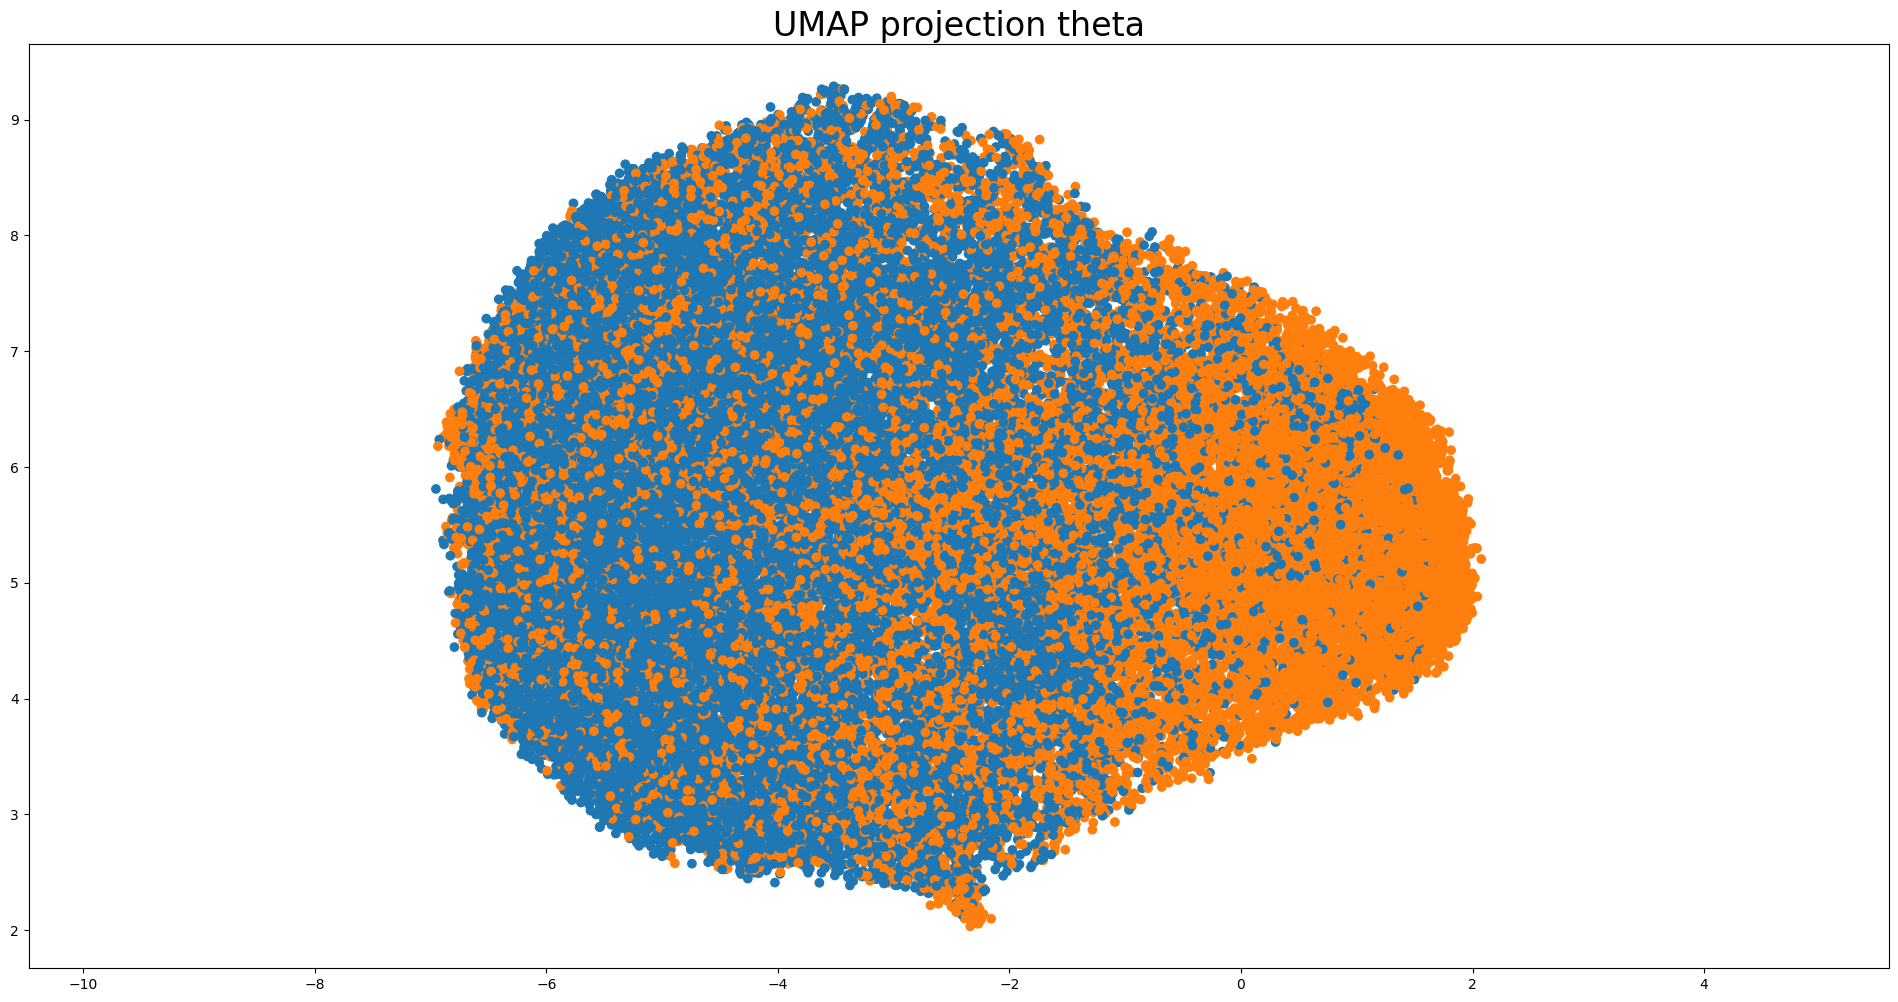

 33%|███▎      | 2/6 [00:37<01:10, 17.58s/it]

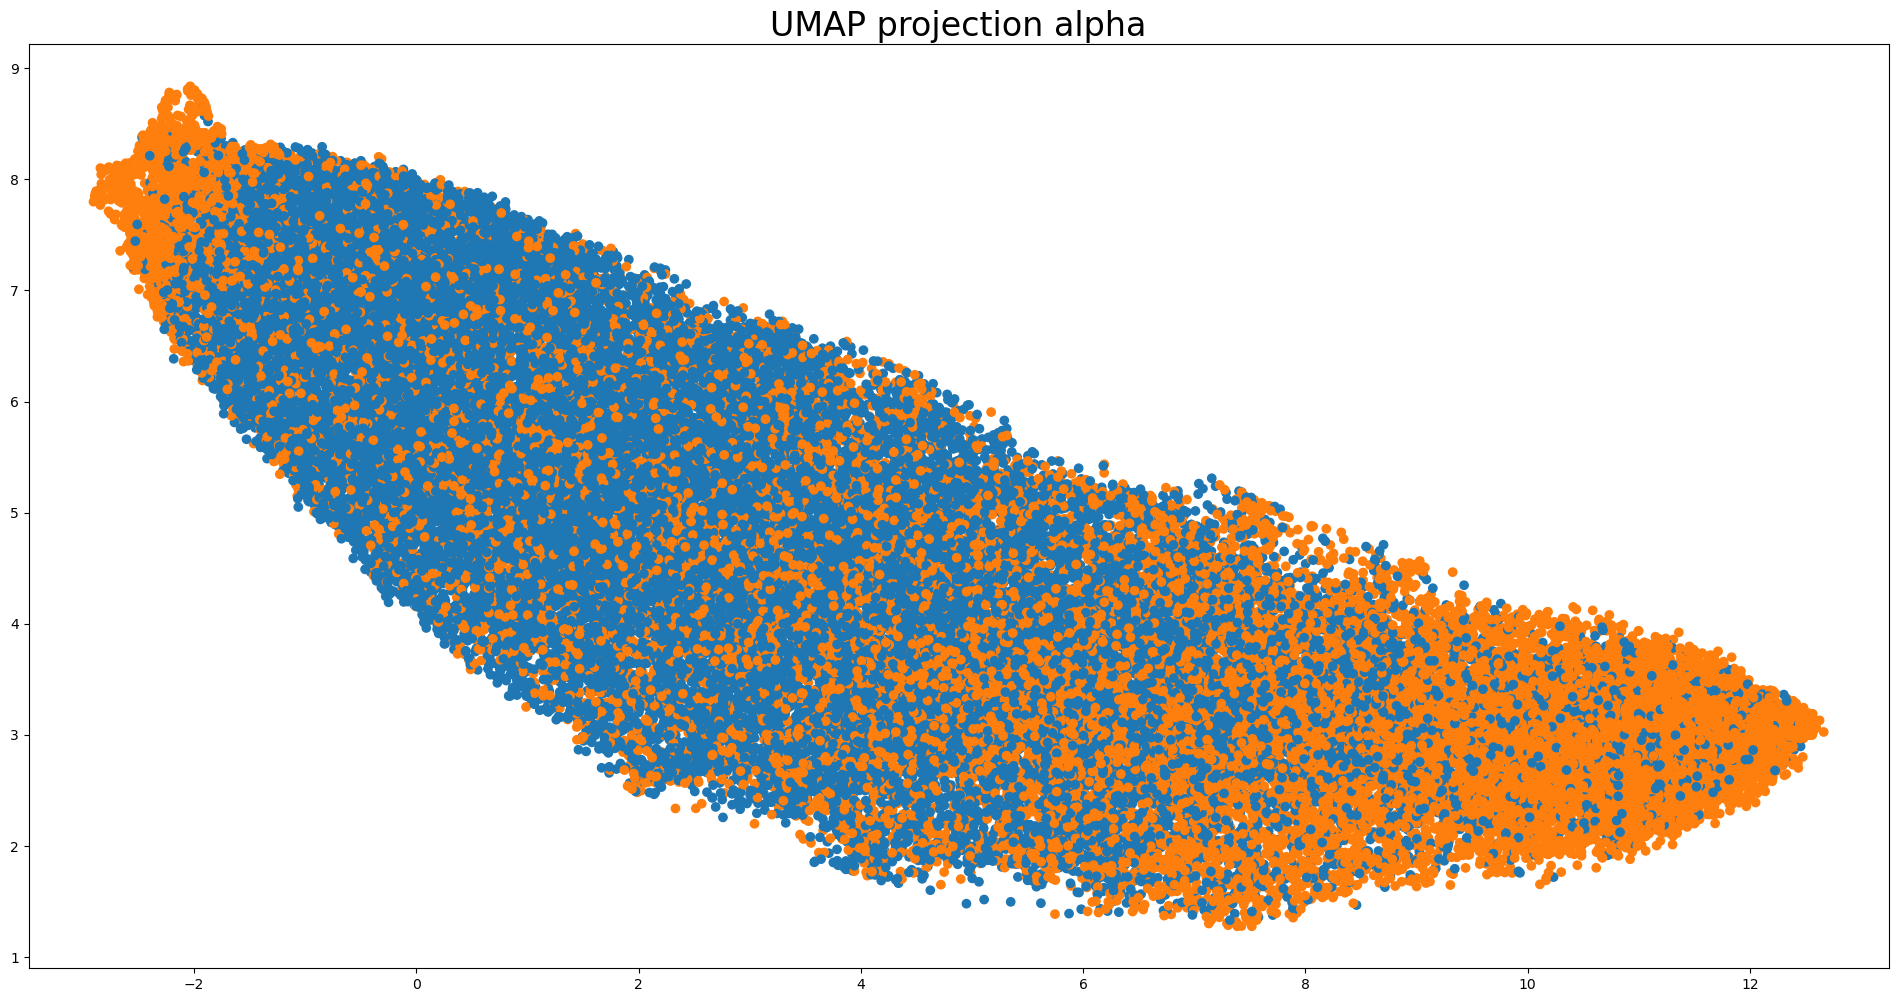

 50%|█████     | 3/6 [00:48<00:43, 14.58s/it]

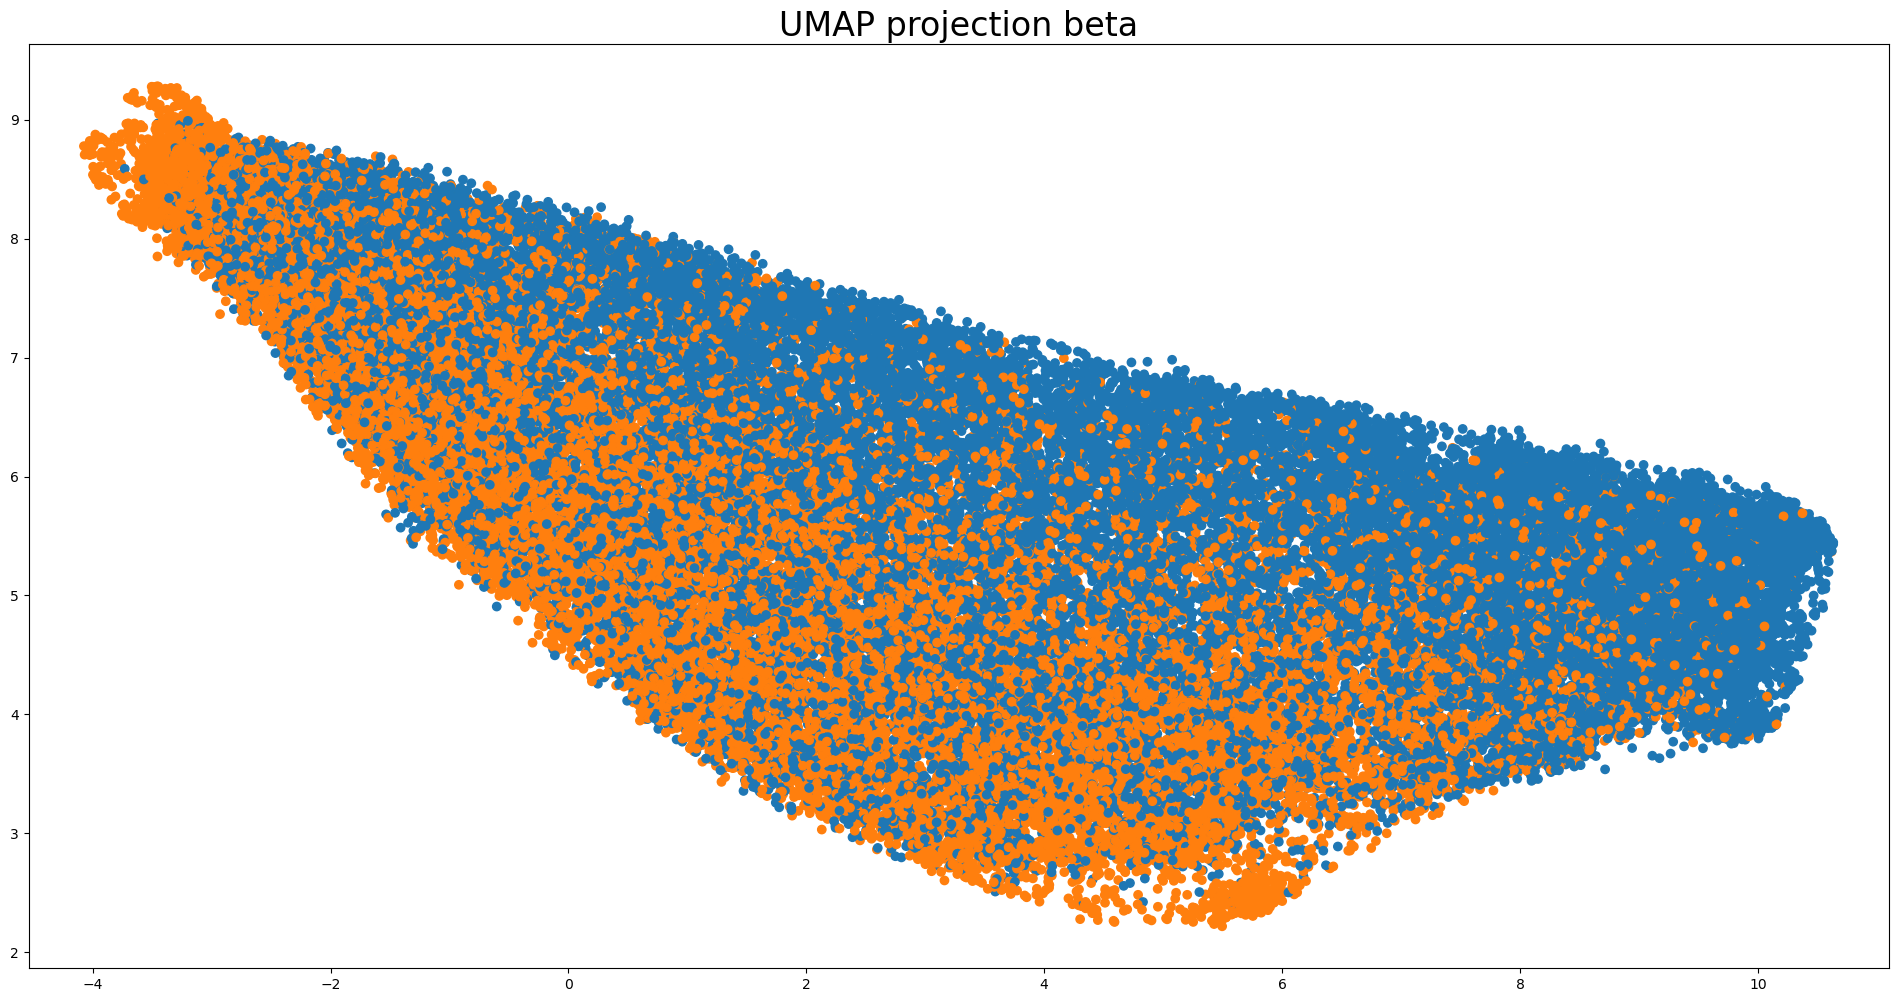

 67%|██████▋   | 4/6 [00:59<00:26, 13.20s/it]

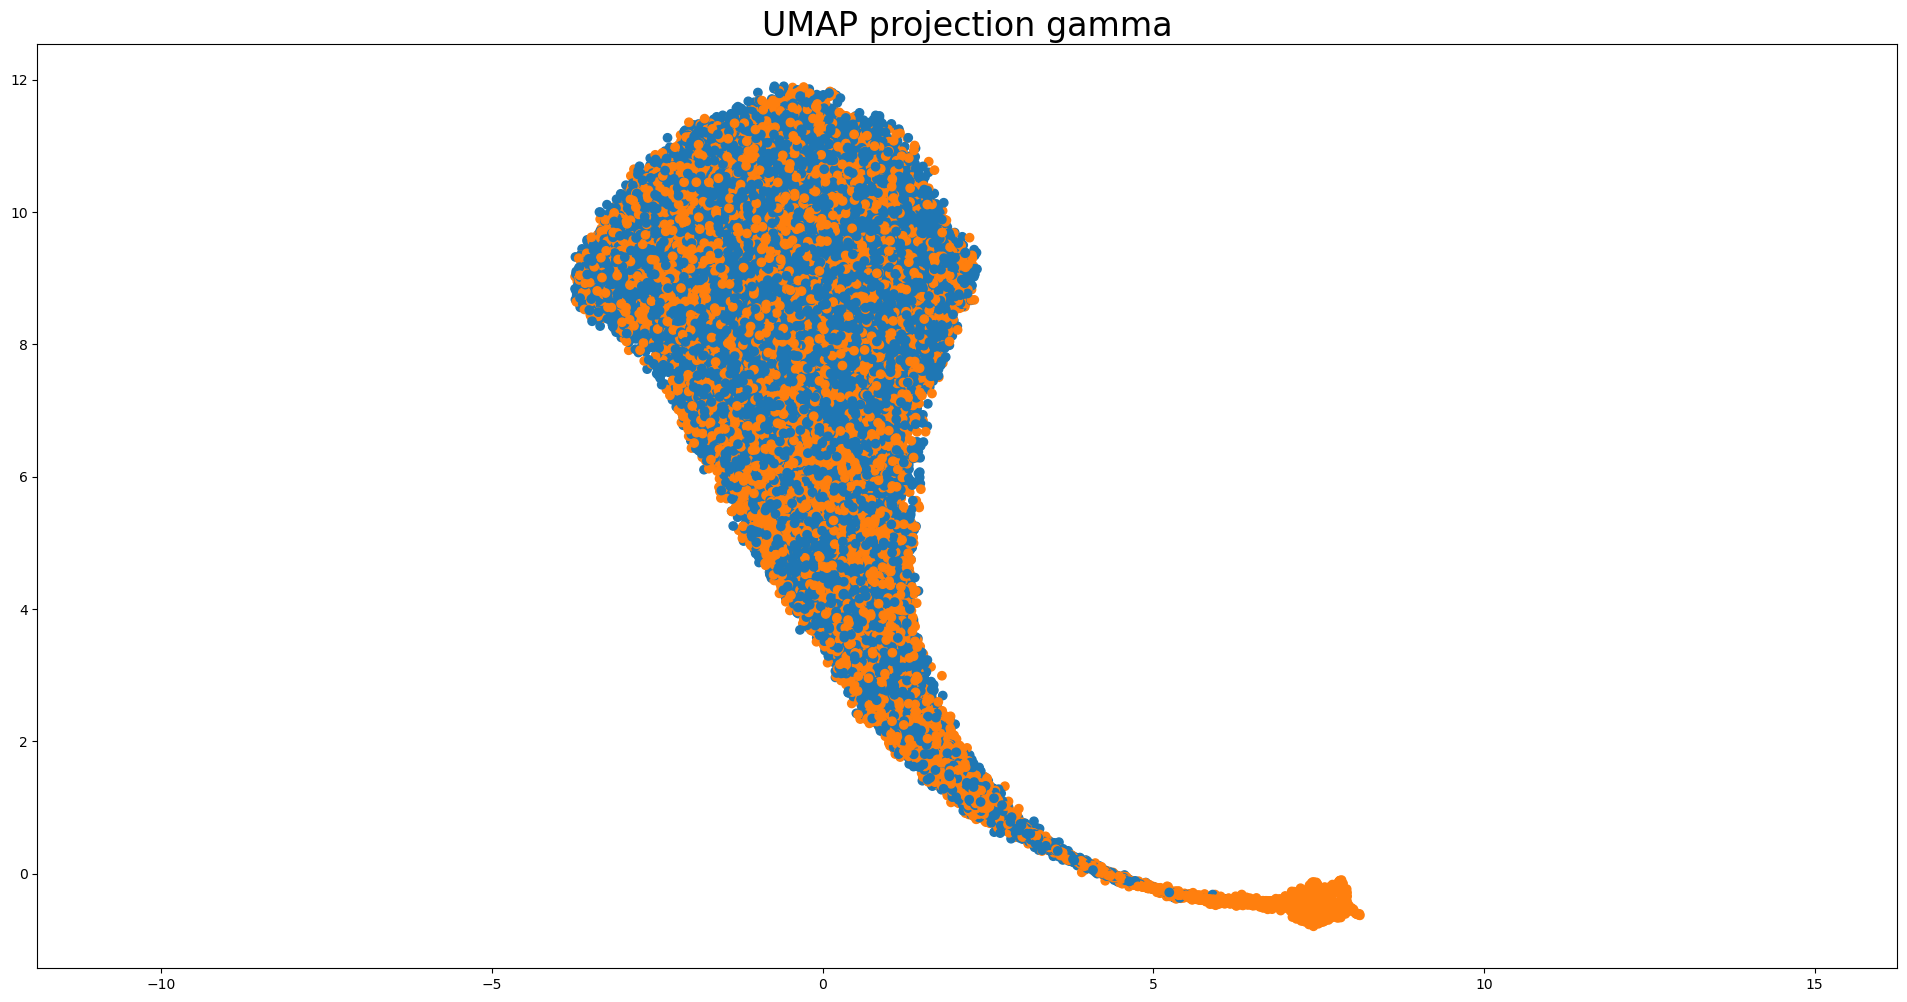

 83%|████████▎ | 5/6 [01:12<00:13, 13.07s/it]

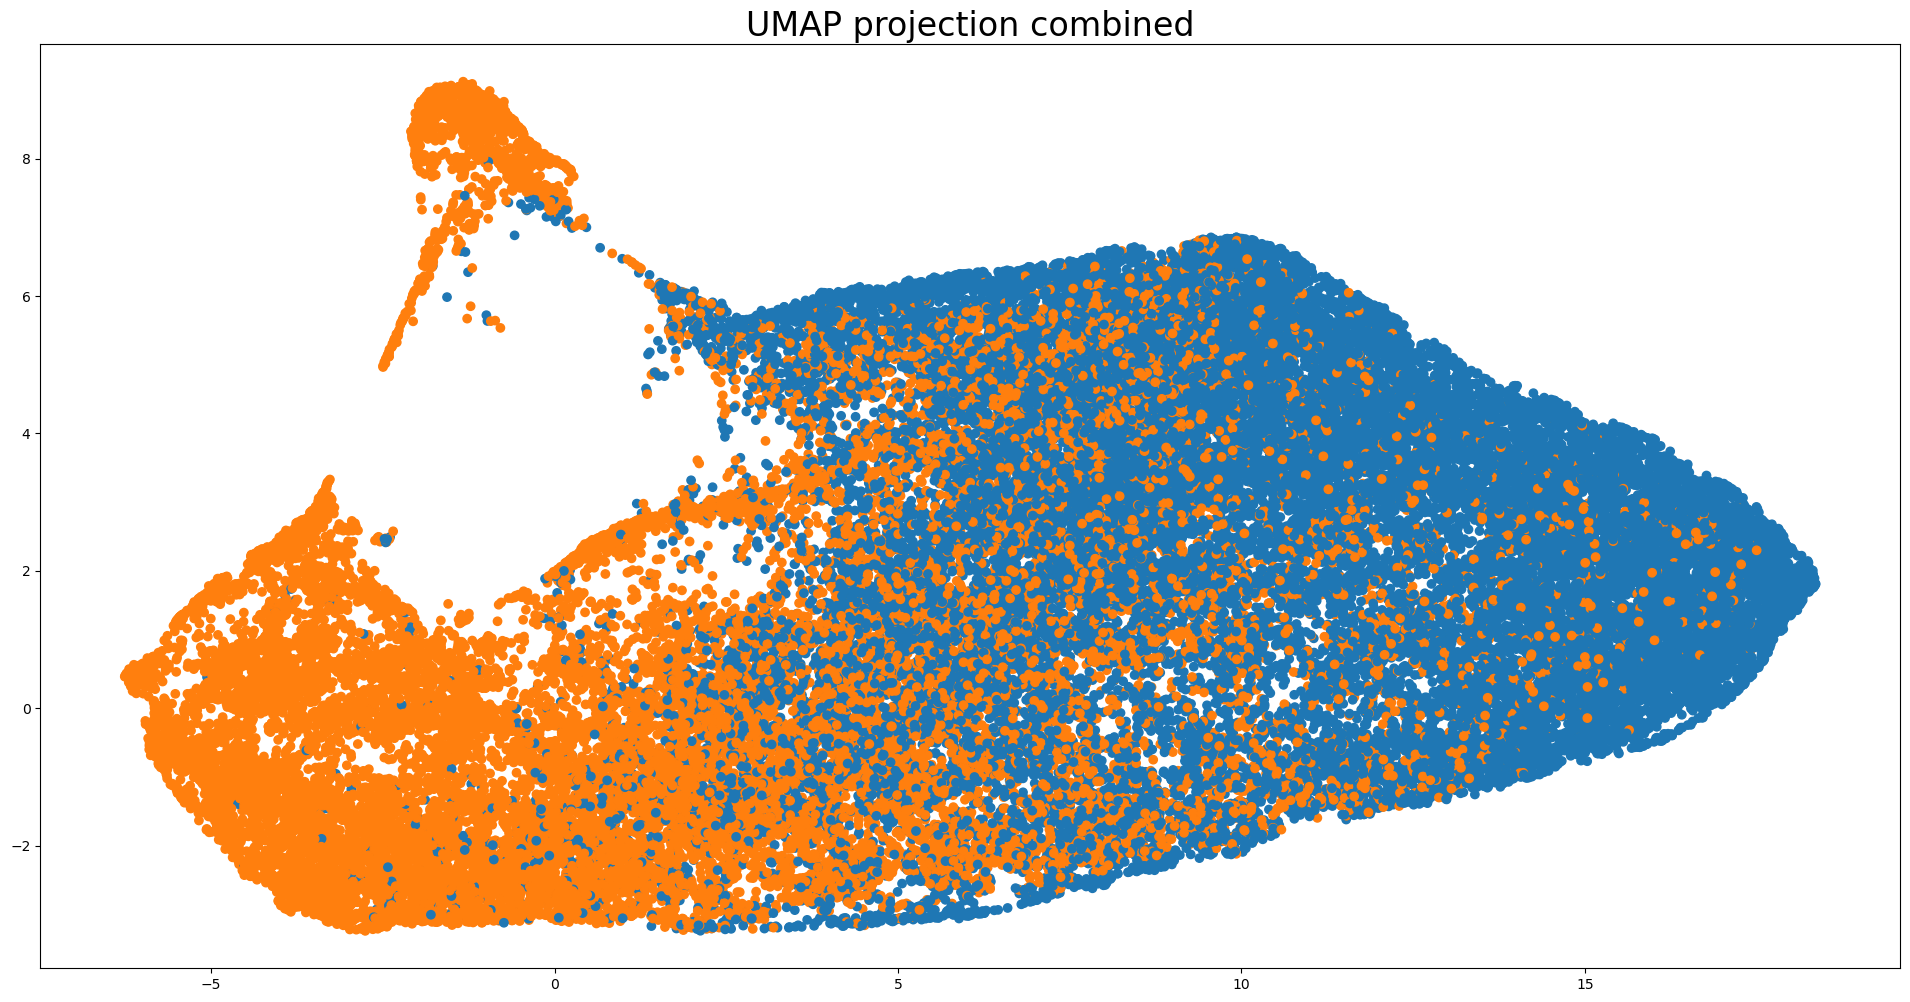

100%|██████████| 6/6 [01:22<00:00, 13.77s/it]


In [25]:
for band in tqdm.tqdm(['delta', 'theta', 'alpha', 'beta', 'gamma', 'combined']):
    if band == 'combined':
        embeddings = reducer2.fit_transform(combined_output_eval_all, job=-1)
    else:
        data = encoding_output_eval_all[band].reshape(encoding_output_eval_all[band].shape[0], -1)
        embeddings = reducer2.fit_transform(data, jobs=-1)
    fig = plt.figure(figsize=(24, 12))
    ax = fig.add_subplot()
    ax.scatter(
        embeddings[:, 0],
        embeddings[:, 1],
        c=[sns.color_palette()[x] for x in output_labels_eval_all])
    plt.gca().set_aspect('equal', 'datalim')
    plt.title(f'UMAP projection {band}', fontsize=24)
    plt.show()

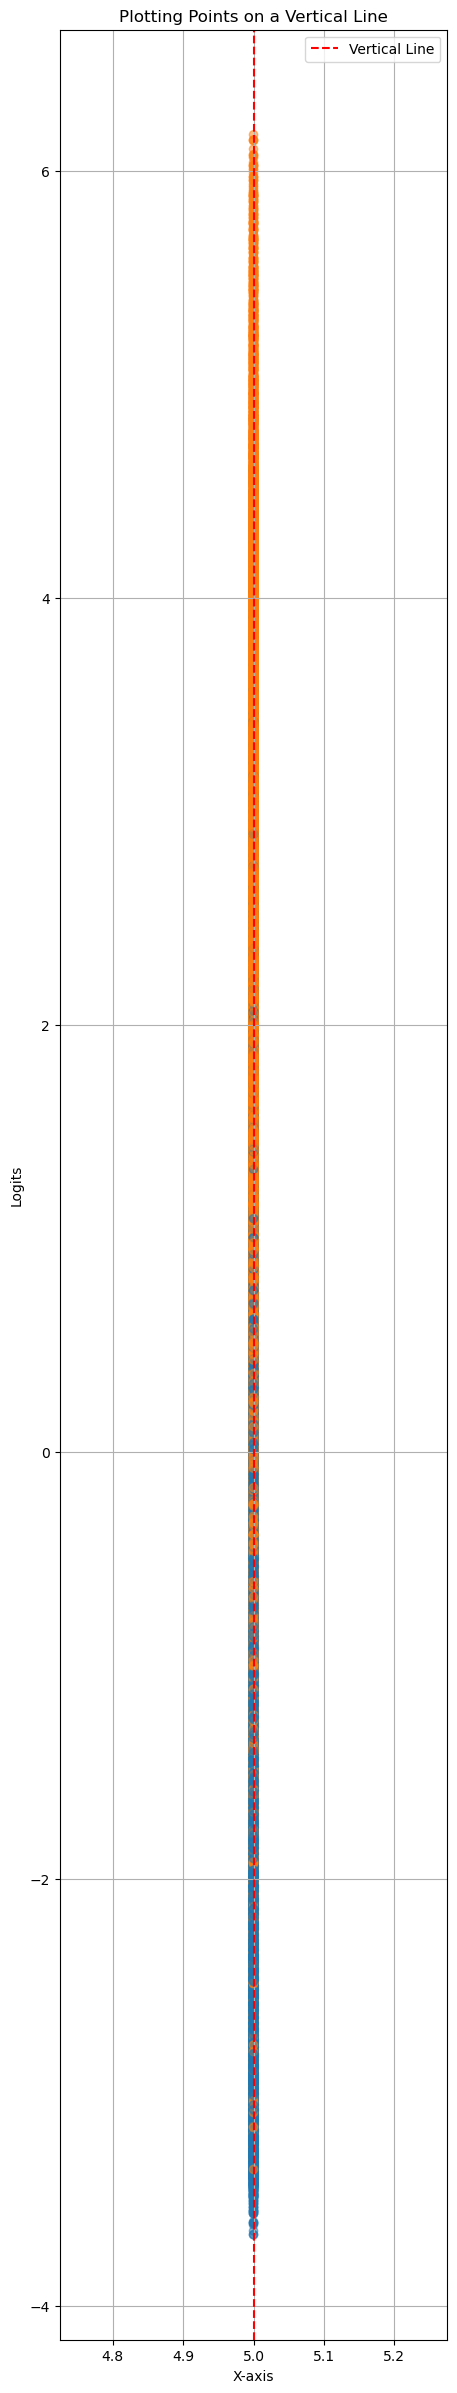

In [26]:
# Define the x-coordinate of the vertical line
x_value = 5

plt.figure(figsize=(5, 30))
# Plot the vertical line
plt.axvline(x=x_value, color='r', linestyle='--', label='Vertical Line')
plt.scatter(
    [x_value] * predictions.shape[0],
    predictions,
    c=[sns.color_palette()[x] for x in output_labels_eval_all],
    alpha=0.5)

# Customize the plot
plt.xlabel('X-axis')
plt.ylabel('Logits')
plt.title('Plotting Points on a Vertical Line')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

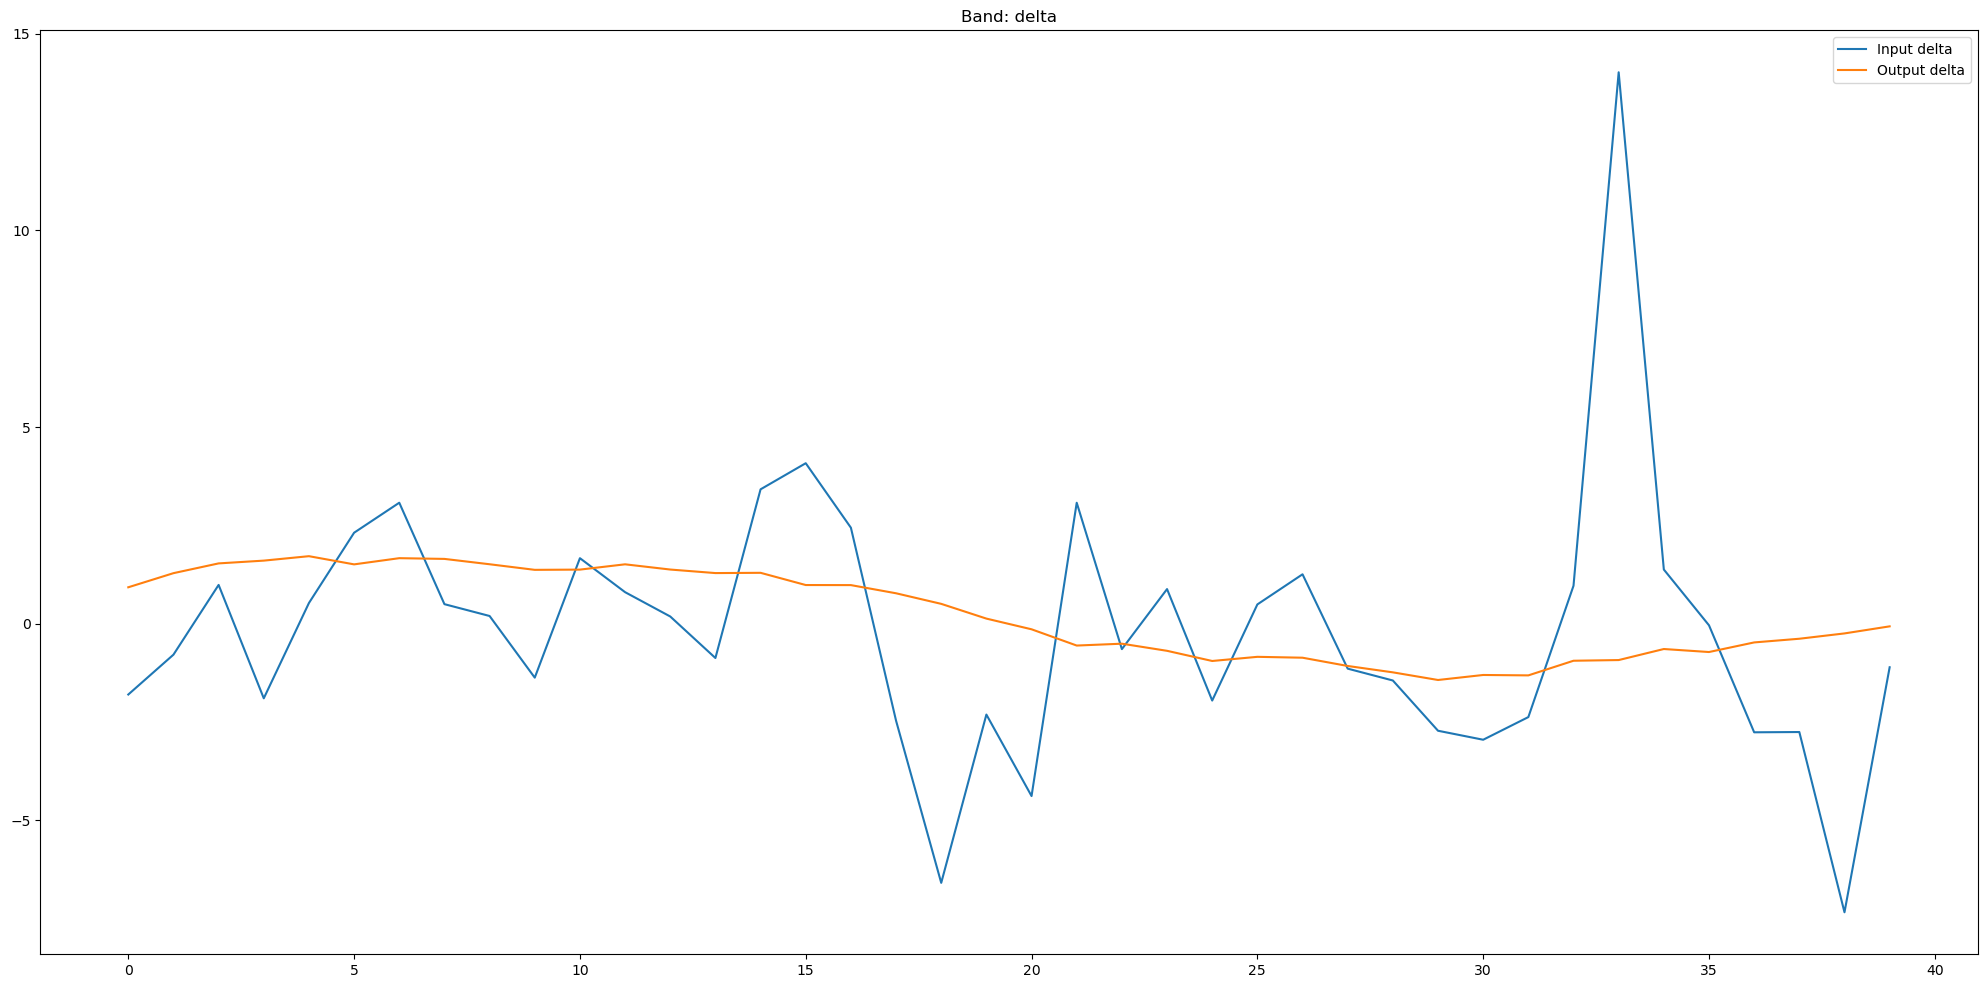

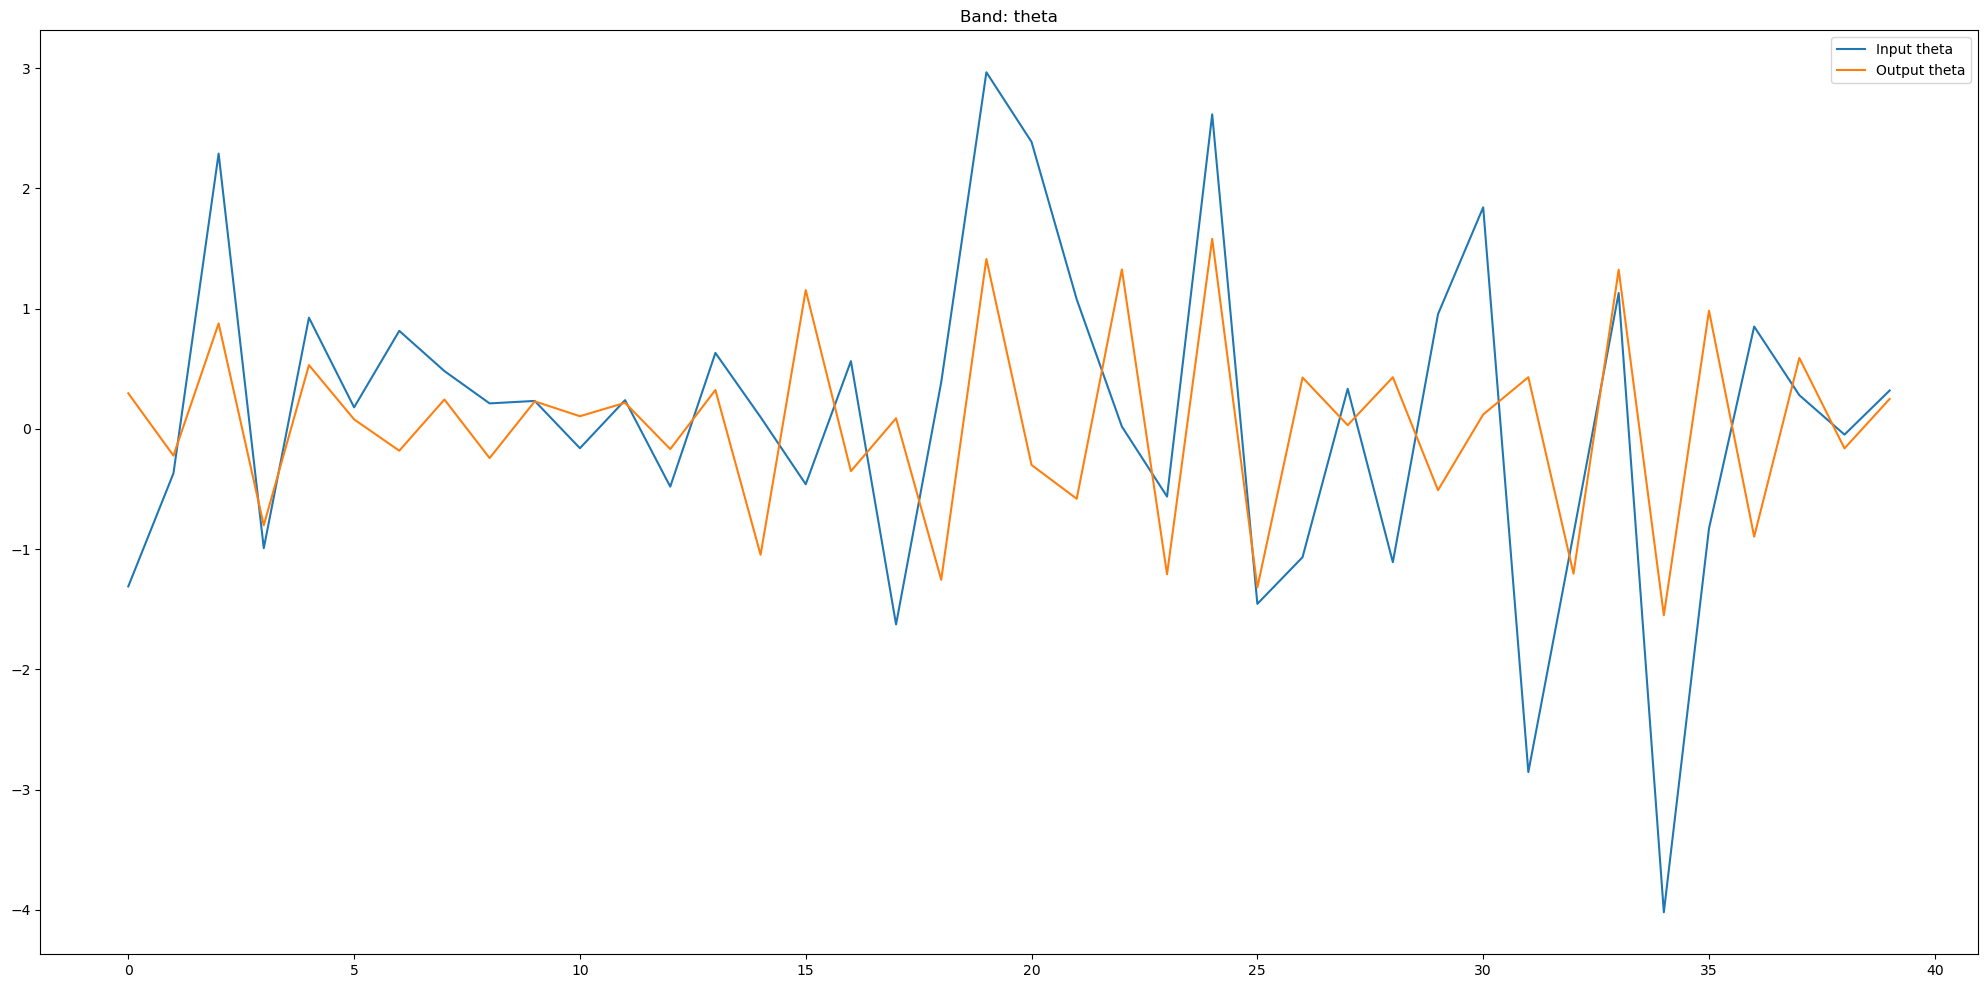

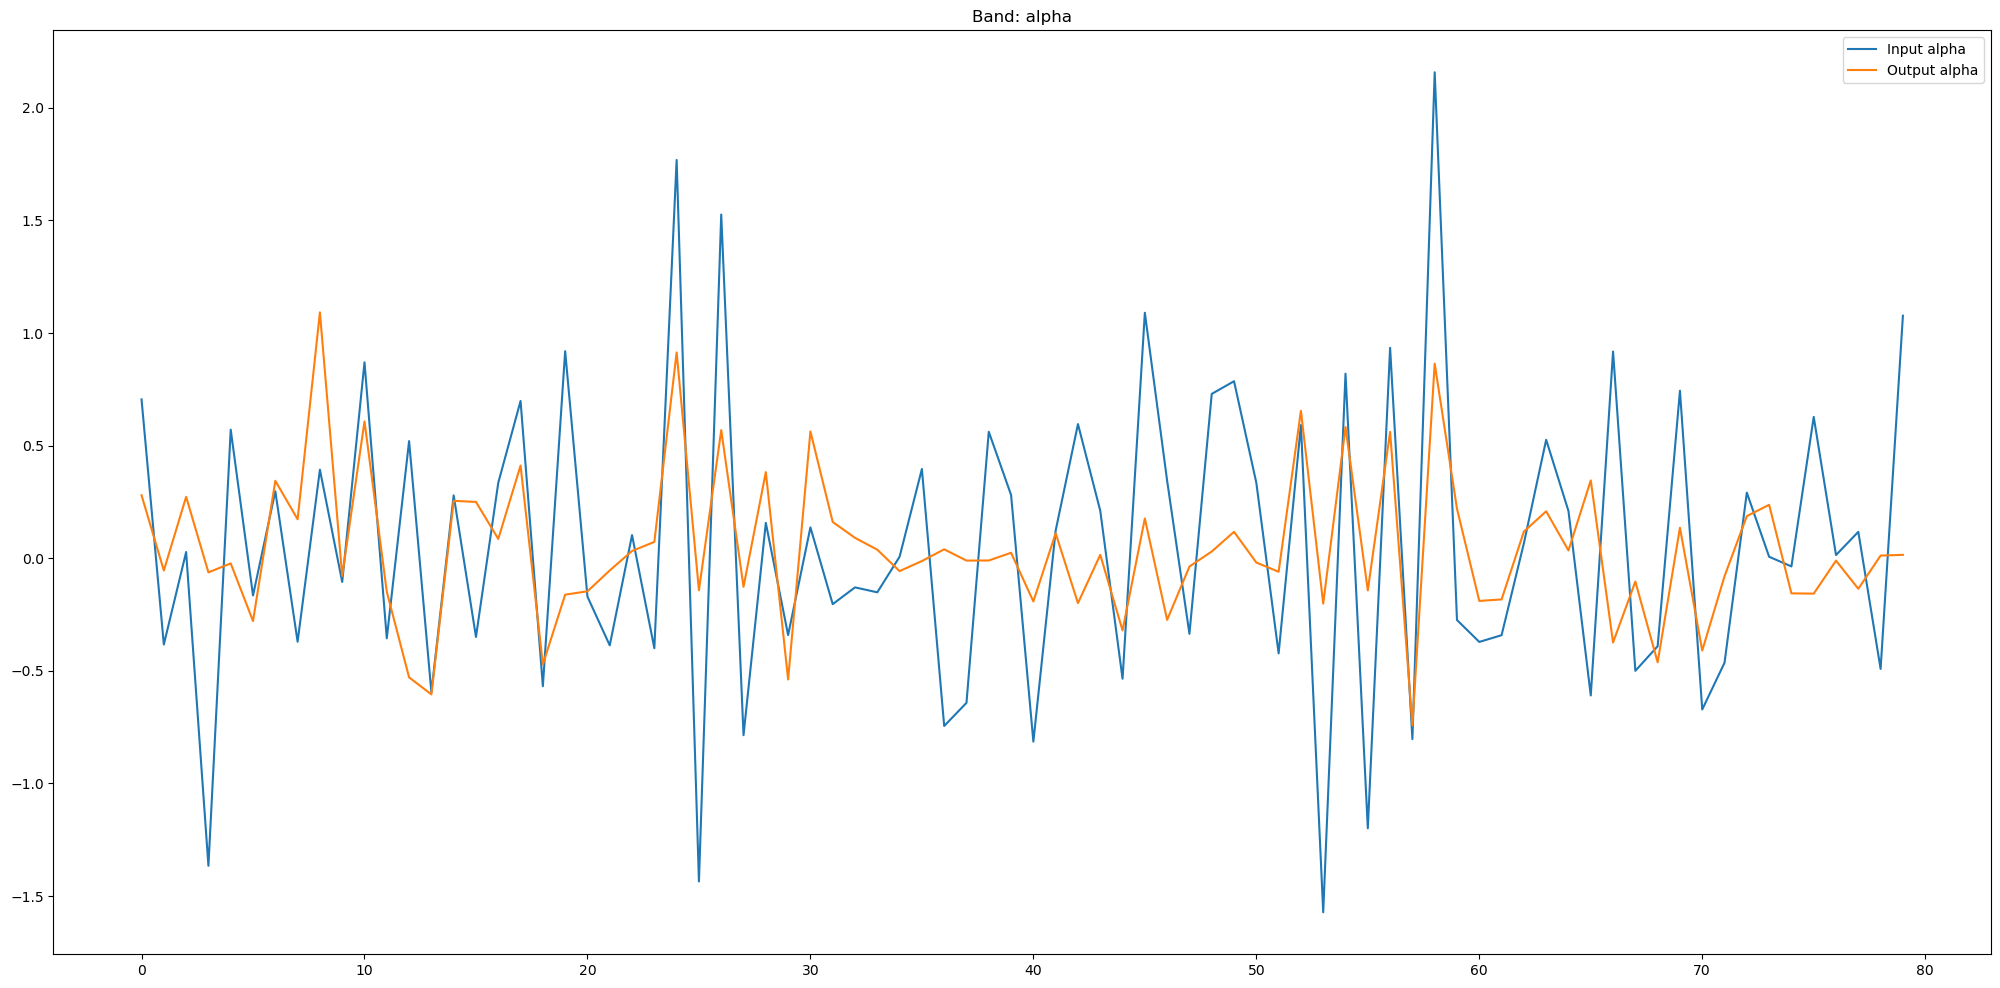

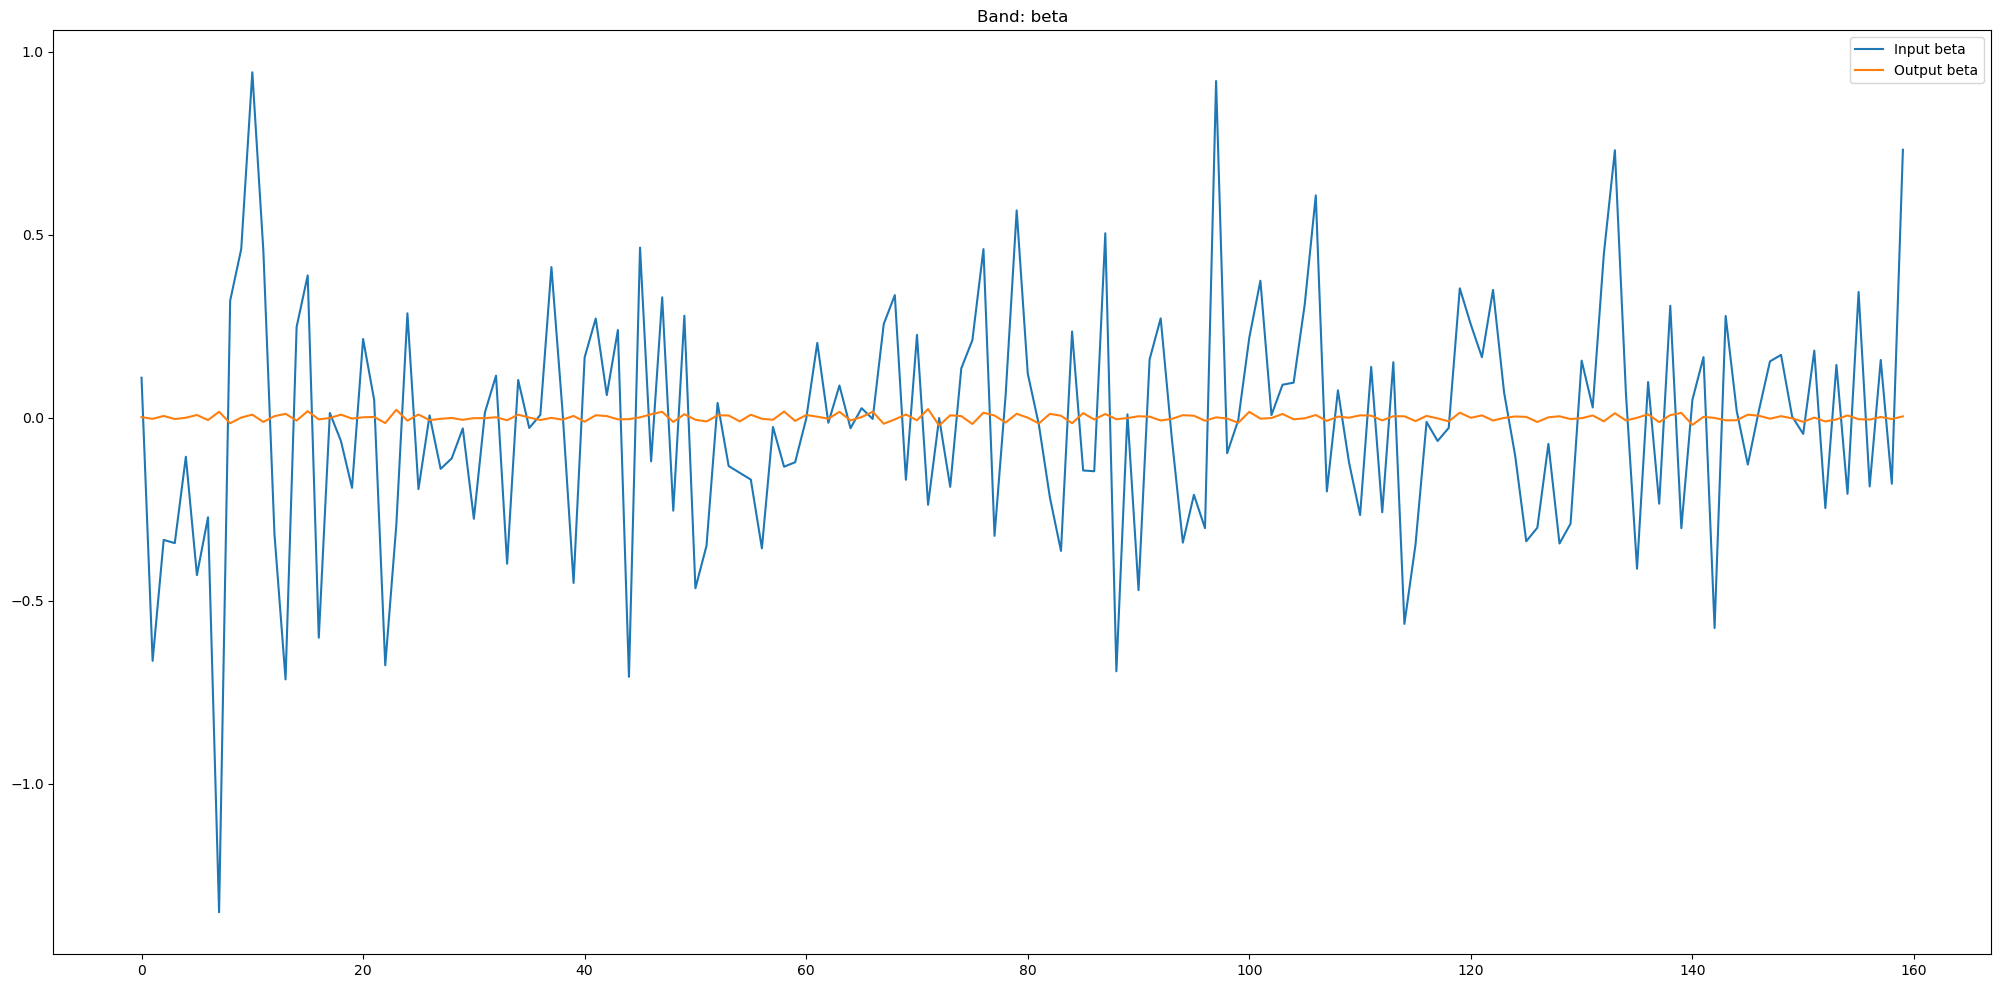

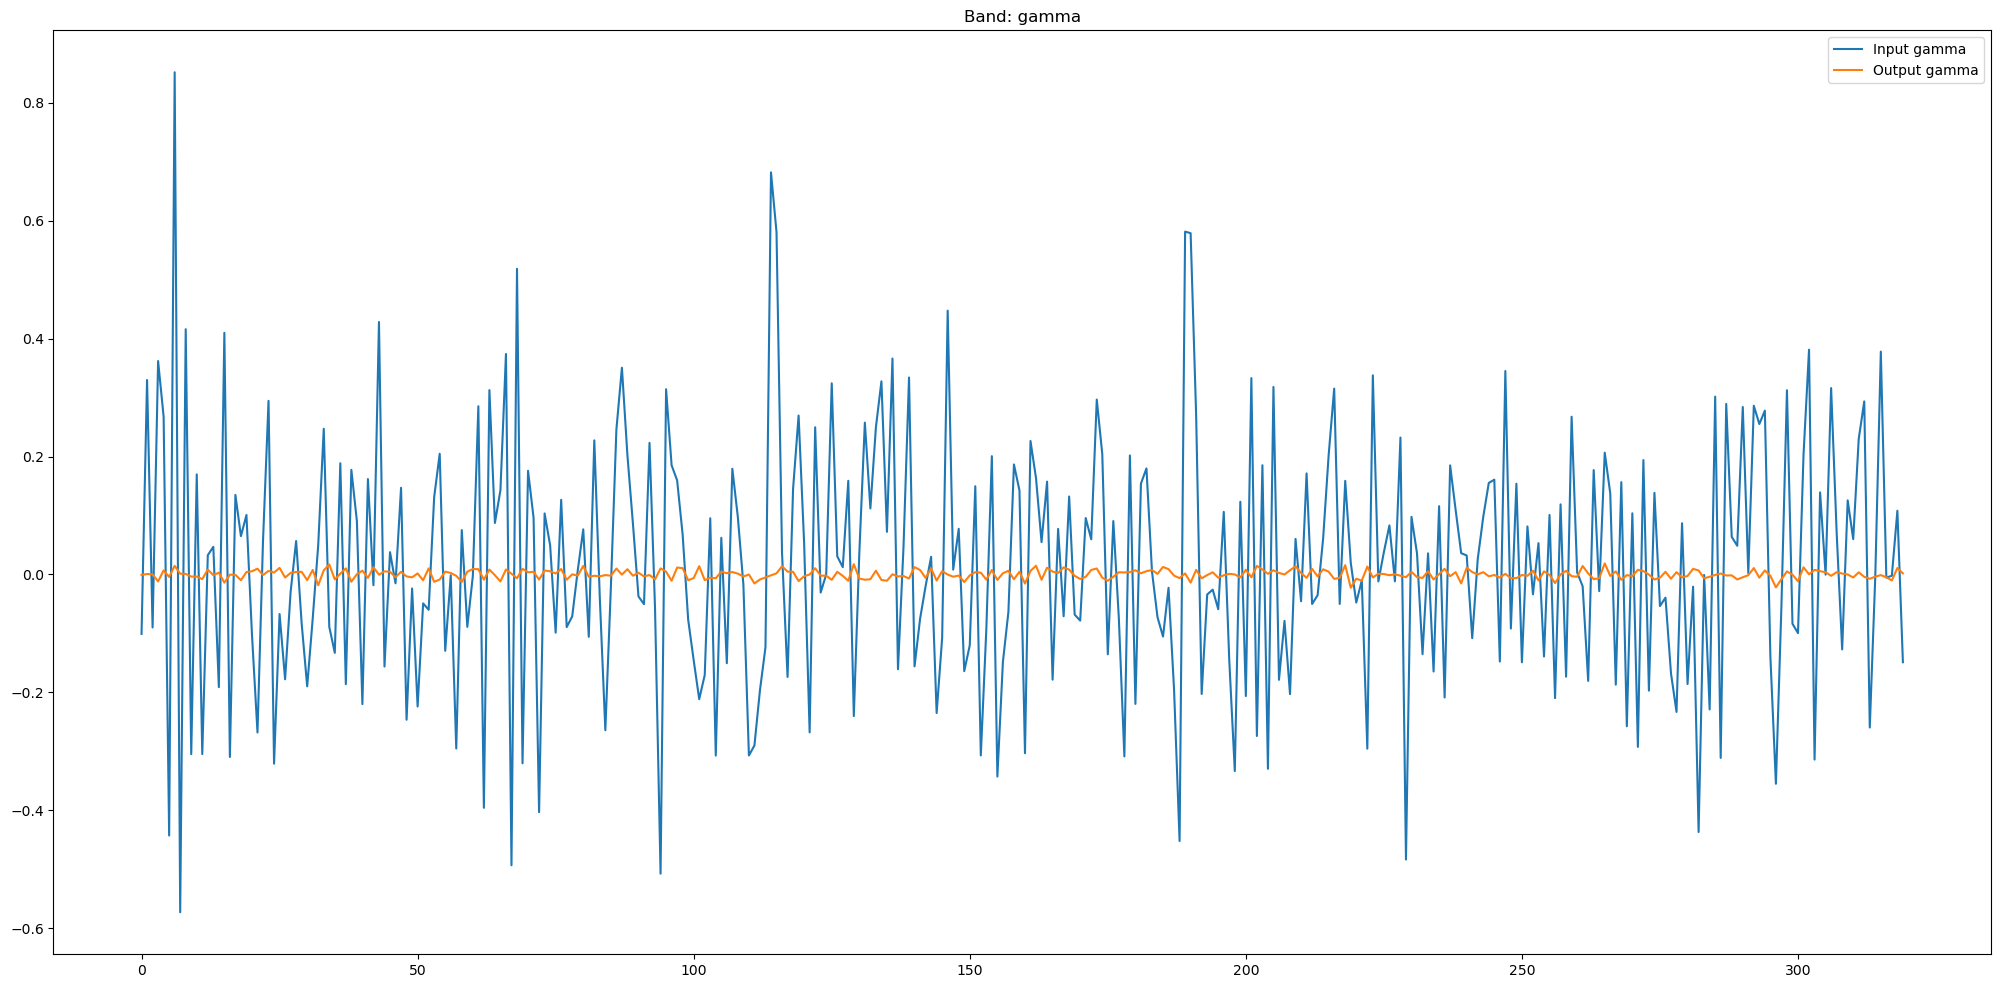

In [29]:
channel = 5
for band in ['delta', 'theta', 'alpha', 'beta', 'gamma']:
    plt.figure(figsize=(25, 12))
    plt.plot(patchified_inputs[band][9, 3, channel, :].cpu().detach().numpy(), label=f"Input {band}")
    decoding_plot = decodings[band].reshape(patchified_inputs[band].shape[0], patchified_inputs[band].shape[1], patchified_inputs[band].shape[2], patchified_inputs[band].shape[3])
    plt.plot(decoding_plot[9, 3, channel, :].cpu().detach().numpy(), label=f"Output {band}")
    plt.title(f"Band: {band}")
    plt.legend()
    plt.show()